In [31]:
from hossam import load_data
from pandas import DataFrame
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb

from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.seasonal import  seasonal_decompose

In [2]:
my_dpi = 200
my_font_name = "./NotoSansKr-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath)
fname = fprop.get_name()
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 6
plt.rcParams['axes.unicode_minus'] = False

In [3]:
origin = load_data("air_passengers")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab13_/air_passengers.xlsx
[desc] 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (144, 2)
열 개수: 2
행 개수: 144

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB
None


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


📝4.데이터 전처리

In [6]:
df1 = origin.set_index("Month")
df1.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


3.데이터의 정상성 확인

📝1.시각화를 통한 확인

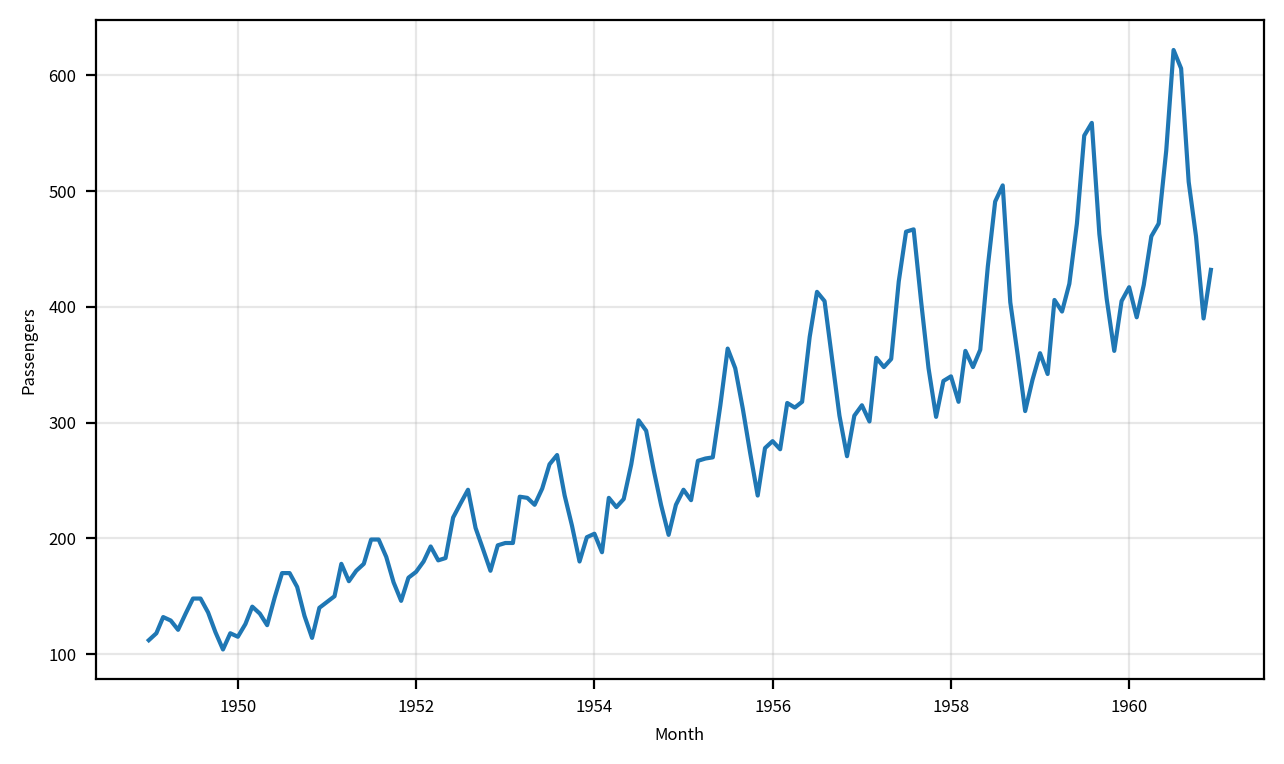

파형이 증가하는 추세로 정상성이 충족되지 않는다.


In [14]:
width_px = 1280
height_px = 760
rows = 1
cols=1
figsize = (width_px /my_dpi, height_px/my_dpi)
fig, ax = plt.subplots(rows,cols,figsize=figsize, dpi=my_dpi)

# 그래프 그리기->seaborn 사용
sb.lineplot(data=df1, x=df1.index,y = "Passengers")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()
print(f"파형이 증가하는 추세로 정상성이 충족되지 않는다.")

📝2.ADF 테스트

In [15]:
ar = adfuller(df1['Passengers'])
ar

(np.float64(0.8153688792060482),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [21]:
print('검정통계량(ADF Statistic):%f' % ar[0])
print('유의수준(p-value):%f'% ar[1])
print('최적차수(num of lags): %f' % ar[2])
print('관측치 개수(num of observations): %f' % ar[3])
print('기각값(Critical Values):')

for key,  value in ar[4].items():
    print('\t%s: %.3f' % (key, value))


print('데이터 정상성 여부:', '정상성 충족' if ar[1] <= 0.05 else '정상성 충족 안함')

검정통계량(ADF Statistic):0.815369
유의수준(p-value):0.991880
최적차수(num of lags): 13.000000
관측치 개수(num of observations): 130.000000
기각값(Critical Values):
	1%: -3.482
	5%: -2.884
	10%: -2.579
데이터 정상성 여부: 정상성 충족 안함


데이터가 정상성을 충족하지 않기 때문에 차분을 통해 정상성을 충족하는 형태로 전처리를 수행해야 한다.

4.차분

📝1차 차분

In [22]:
df2 = df1.diff().dropna()
df2

,Passengers
Month,
1949-02-01,6.0
1949-03-01,14.0
1949-04-01,-3.0
1949-05-01,-8.0
1949-06-01,14.0
...,...
1960-08-01,-16.0
1960-09-01,-98.0
1960-10-01,-47.0


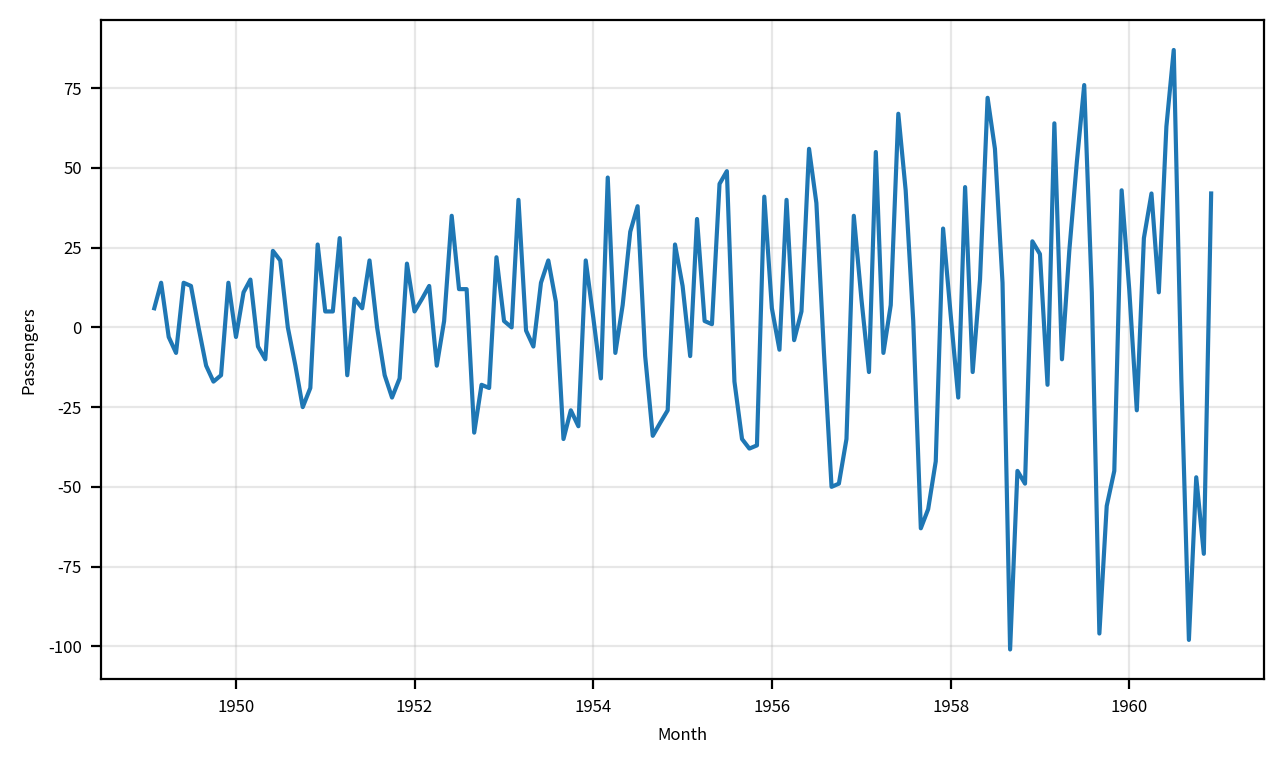

검정통계량(ADF Statistic): -2.829267
유의수준(p-value):0.054213
최적차수(num of lags): 12.000000
관측치 개수(num of observations): 130.000000
기각값(Critical Values):
	1%: -3.482
	5%: -2.884
	10%: -2.579
데이터 정상성 여부: 정상성 충족 안함


In [26]:
width_px = 1280
height_px = 760
rows = 1
cols=1
figsize = (width_px /my_dpi, height_px/my_dpi)
fig, ax = plt.subplots(rows,cols,figsize=figsize, dpi=my_dpi)

# 그래프 그리기->seaborn 사용
sb.lineplot(data=df2, x=df2.index,y = "Passengers")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

# ADF 검정
ar = adfuller(df2['Passengers'])

print('검정통계량(ADF Statistic): %f' % ar[0])
print('유의수준(p-value):%f' % ar[1])
print('최적차수(num of lags): %f' % ar[2])
print('관측치 개수(num of observations): %f' % ar[3])
print('기각값(Critical Values):')

for key, value in ar[4].items():
    print('\t%s: %.3f' %(key, value))


print('데이터 정상성 여부:' , '정상성 충족' if ar[1] <= 0.05 else '정상성 충족 안함')

📝2차 차분

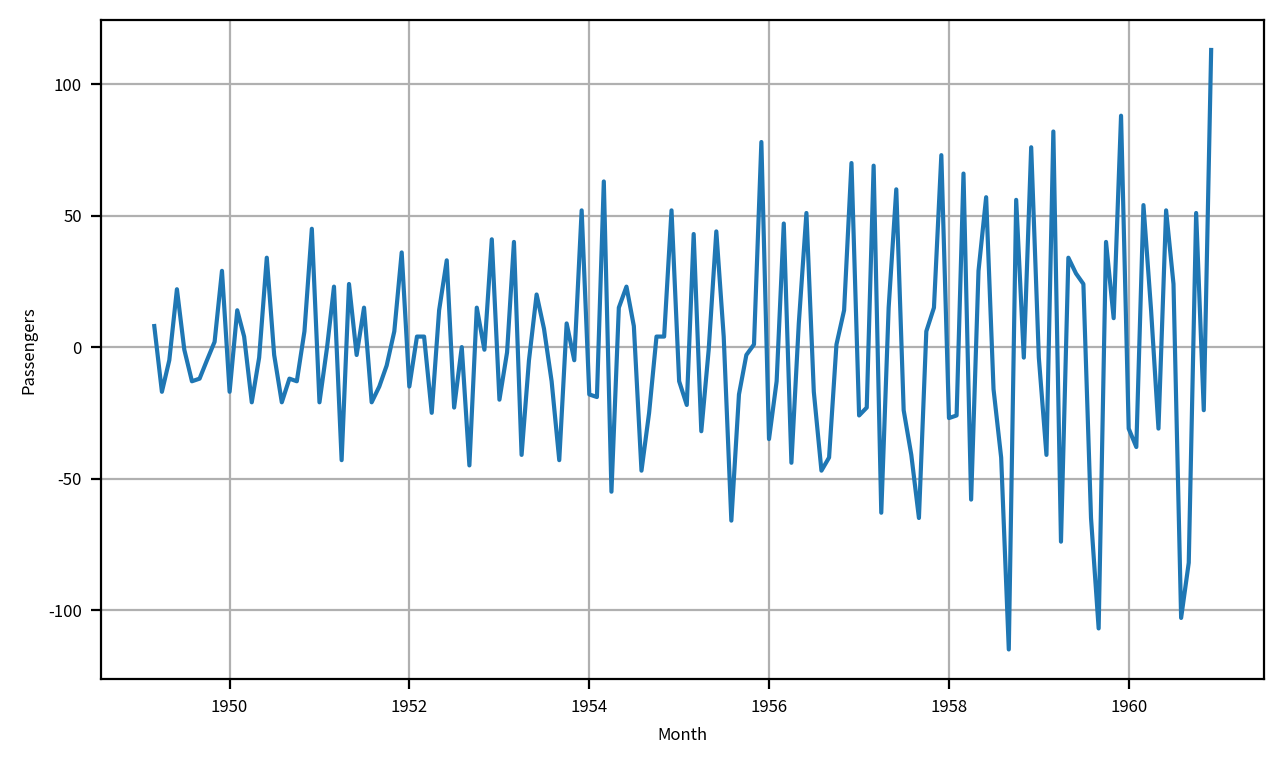

검정통계량(ADF Statistic): -16.384232
유의수준(p-value): 0.000000
최적차수(num of lags): 11.000000
관측치 개수(num of observations): 130.000000
기각값(Critical Values) % f:
	1%: -3.482
	5%: -2.884
	10%: -2.579
데이터 정상성 여부: 정상성충족


In [32]:
df3 = df2.diff().dropna()

width_px = 1280
height_px = 760
rows = 1
cols=1
figsize = (width_px /my_dpi, height_px/my_dpi)
fig, ax = plt.subplots(rows,cols,figsize=figsize, dpi=my_dpi)

# 그래프 그리기->seaborn 사용
sb.lineplot(data=df3, x=df3.index, y = 'Passengers')


ax.grid()


plt.tight_layout()
plt.show()
plt.close()

# ADF 검정
ar = adfuller(df3['Passengers'])
print('검정통계량(ADF Statistic): %f' % ar[0])
print('유의수준(p-value): %f' % ar[1])
print('최적차수(num of lags): %f' % ar[2])
print('관측치 개수(num of observations): %f' % ar[3])
print('기각값(Critical Values) % f:' )

for key, value in ar[4].items():
    print('\t%s: %.3f' %(key, value))

print('데이터 정상성 여부:', '정상성충족' if ar[1] <= 0.05 else '정상성 충족 안함') 

시계열의 탐색

In [34]:
origin = load_data("air_passengers")
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab13_/air_passengers.xlsx
[desc] 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (144, 2)
열 개수: 2
행 개수: 144

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB
None


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


# 2.데이터 전처리

📝1. 시계열 인덱스 설정

In [38]:
df1 = origin.set_index('Month')
df1

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


📝2.차분

=====0차 차분=====


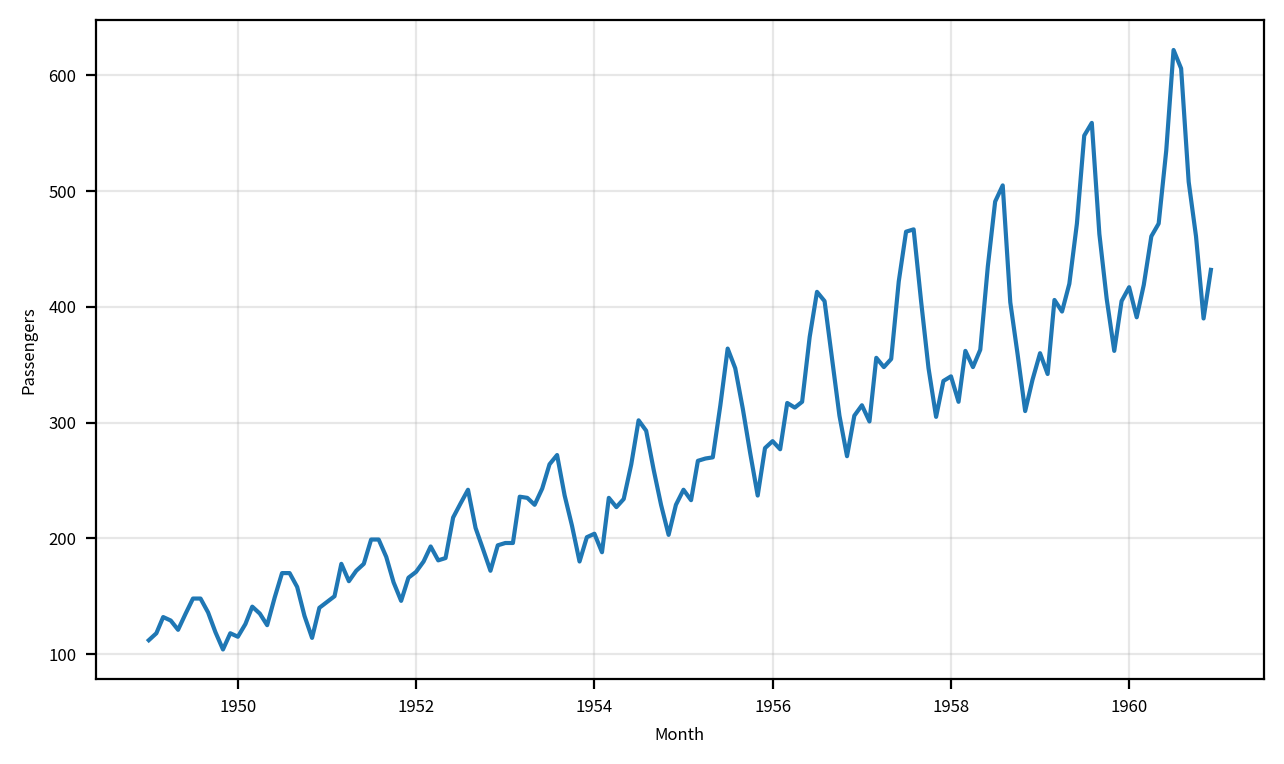

,0
ADF Statistic,0.815369
p-value,0.99188
num of lags,13
num of observations,130
result,False


=====1차 차분=====


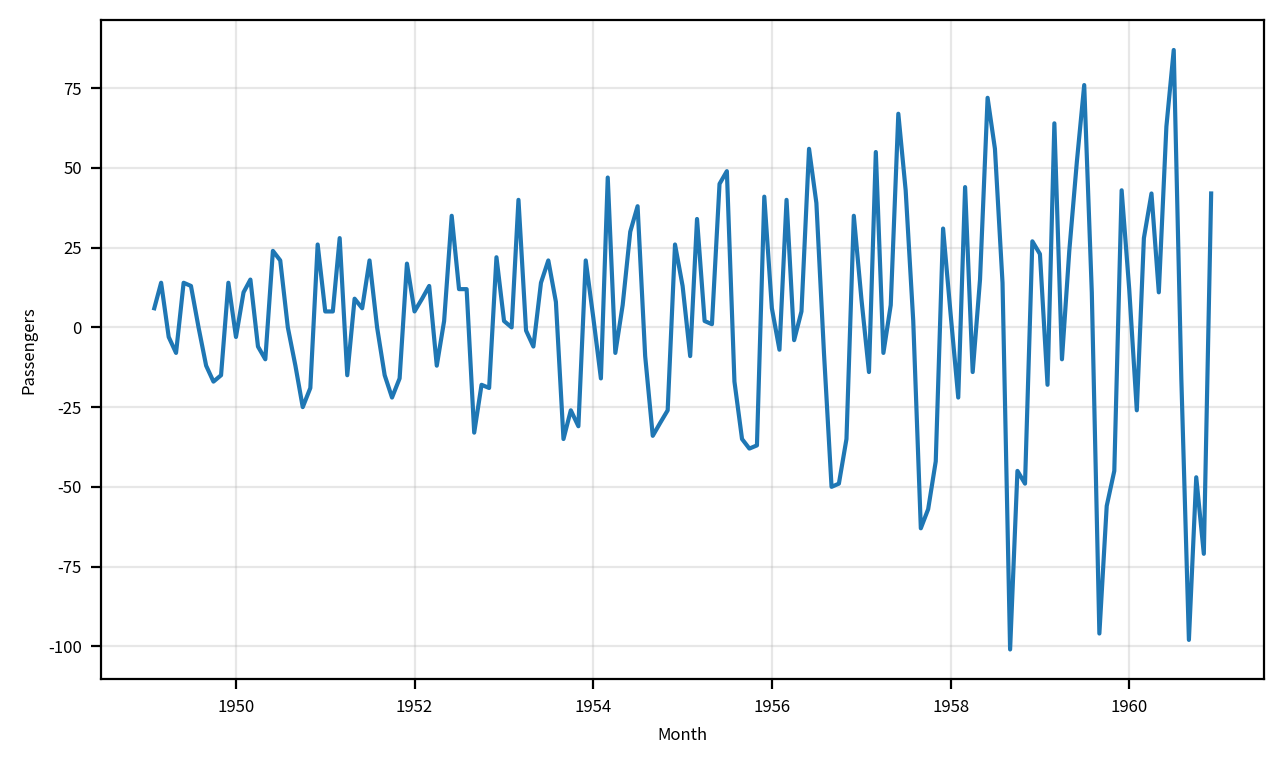

,0
ADF Statistic,-2.829267
p-value,0.054213
num of lags,12
num of observations,130
result,False


=====2차 차분=====


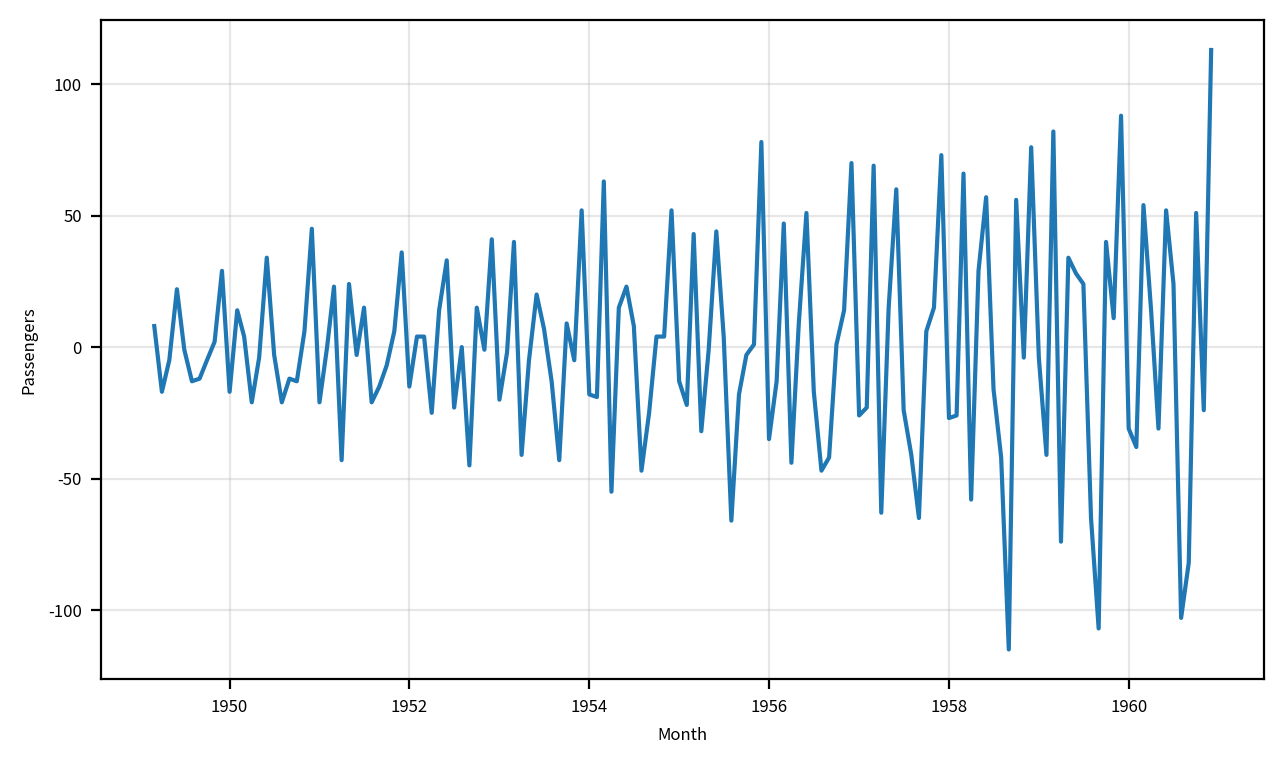

,0
ADF Statistic,-16.384232
p-value,0.0
num of lags,11
num of observations,130
result,True


In [41]:
diff_df = df1.copy()
yname = 'Passengers'
count = 0

while True:
    print(f"====={count}차 차분=====")

    # 시계열 그래프
    width_px = 1280
    height_px = 760
    rows = 1
    cols=1
    figsize = (width_px /my_dpi, height_px/my_dpi)
    fig, ax = plt.subplots(rows,cols,figsize=figsize, dpi=my_dpi)
    sb.lineplot(data=diff_df, x=diff_df.index, y=yname)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()

    ar = adfuller(diff_df[yname])
    ar_dict = {
        'ADF Statistic':ar[0],
        'p-value':ar[1],
        'num of lags':ar[2],
        'num of observations':ar[3]
    }

    ar_dict['result'] = True if ar[1] <= 0.05 else False

    adf = DataFrame([ar_dict]).T
    display(adf)

    # 정상성 충족이라면 반복 중단
    if ar[1] <= 0.05:
        break

    count += 1
    diff_df = diff_df.diff().dropna()


# 3.평균이동법

📝[1]차분되지 않은 원본에 대한 3개월, 6개월, 9개월 평균

✏️평균이동 수행

In [44]:
df2 = df1.copy()

df2['rolling3'] = df2['Passengers'].rolling(3).mean()
df2['rolling6'] = df2['Passengers'].rolling(6).mean()
df2['rolling9'] = df2['Passengers'].rolling(9).mean()

df2.head()

,Passengers,rolling3,rolling6,rolling9
Month,,,,
1949-01-01,112,NaN,NaN,NaN
1949-02-01,118,NaN,NaN,NaN
1949-03-01,132,120.666667,NaN,NaN
1949-04-01,129,126.333333,NaN,NaN
1949-05-01,121,127.333333,NaN,NaN


✏️시계열 그래프 확인

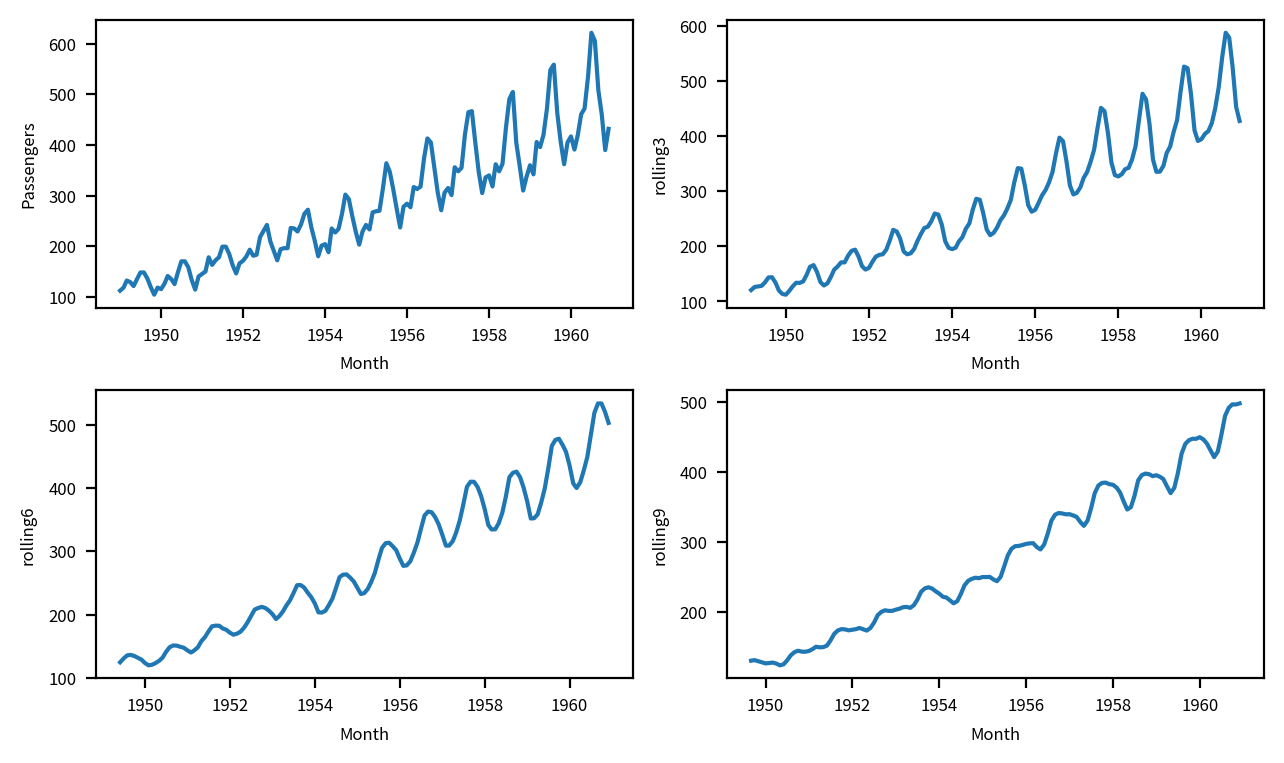

In [48]:
width_px = 1280
height_px = 760
rows = 2
cols=2
figsize = (width_px /my_dpi, height_px/my_dpi)
fig, ax = plt.subplots(rows,cols,figsize=figsize, dpi=my_dpi)

sb.lineplot(df2, x=df2.index, y='Passengers', ax=ax[0][0])
sb.lineplot(df2, x=df2.index, y='rolling3', ax=ax[0][1])
sb.lineplot(df2, x=df2.index, y='rolling6', ax=ax[1][0])
sb.lineplot(df2, x=df2.index, y='rolling9', ax=ax[1][1])

plt.tight_layout()
plt.show()
plt.close()




데이터의 평균을 이동하여 점점 더 그래프가 단순해진다.<br>
이를 통해 월별 승객 수가 꾸준히 증가하는 추세라는 것을 알 수 있다.<br>
원본 데이터로 확인할 경우 전반적인 경향을 알 수 있다.

📝[2]차분된 데이터 대한 3개월, 6개월, 9개월 평균

In [55]:
df3 = diff_df.copy()

df3['rolling3'] = df3['Passengers'].rolling(3).mean()
df3['rolling6'] = df3['Passengers'].rolling(6).mean()
df3['rolling9'] = df3['Passengers'].rolling(9).mean()

df3.head()

,Passengers,rolling3,rolling6,rolling9
Month,,,,
1949-03-01,8.0,NaN,NaN,NaN
1949-04-01,-17.0,NaN,NaN,NaN
1949-05-01,-5.0,-4.666667,NaN,NaN
1949-06-01,22.0,0.000000,NaN,NaN
1949-07-01,-1.0,5.333333,NaN,NaN


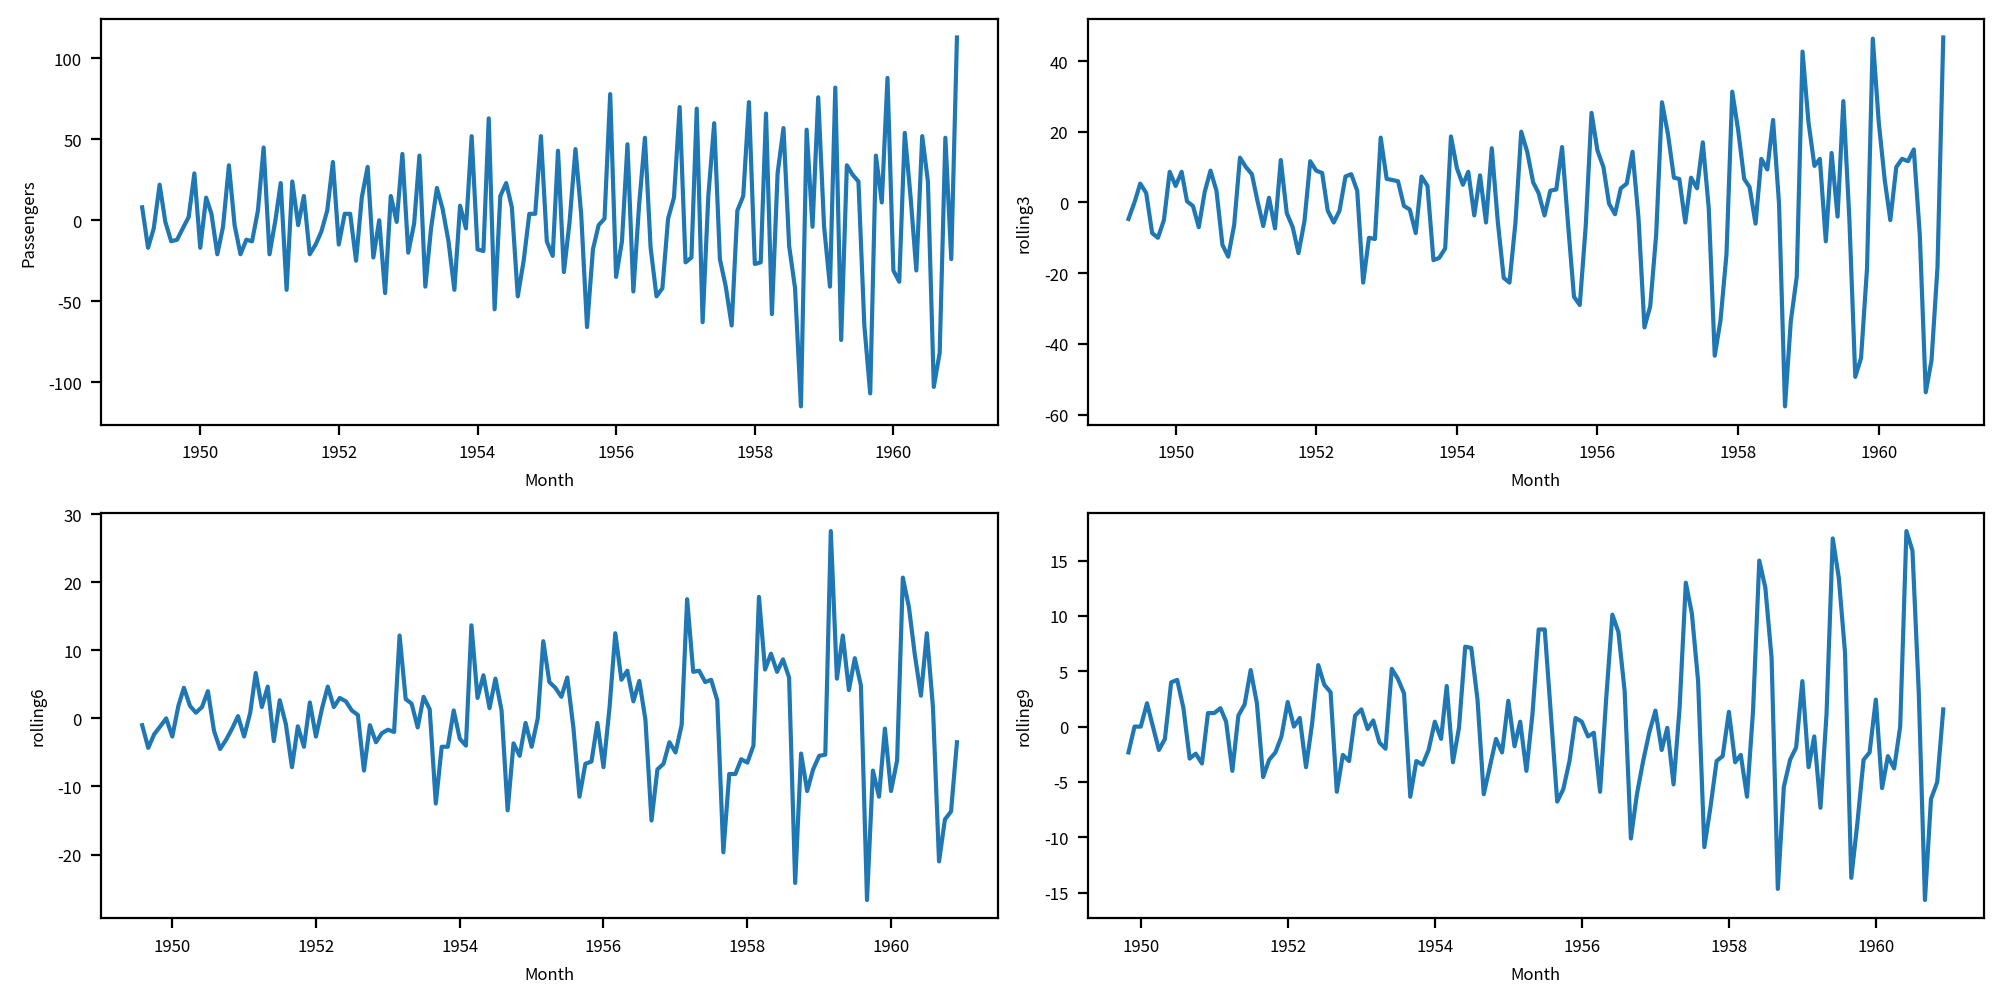

In [58]:
width_px = 2000
height_px = 1000
rows = 2
cols = 2
figsize = (width_px/ my_dpi,height_px/my_dpi)

fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi = my_dpi)

sb.lineplot(df3 , x=df3.index, y='Passengers', ax=ax[0][0])
sb.lineplot(df3 , x=df3.index, y='rolling3', ax=ax[0][1])
sb.lineplot(df3 , x=df3.index, y='rolling6', ax=ax[1][0])
sb.lineplot(df3 , x=df3.index, y='rolling9', ax=ax[1][1])

plt.tight_layout()
plt.show()
plt.close()

# 4.지수평활법

📝(1)원본에 대한 지수평활법

In [59]:
df4 = df1.copy()

df4['ewm3'] = df4['Passengers'].ewm(3).mean()
df4['ewm6'] = df4['Passengers'].ewm(6).mean()
df4['ewm9'] = df4['Passengers'].ewm(9).mean()

df4.head()

,Passengers,ewm3,ewm6,ewm9
Month,,,,
1949-01-01,112,112.000000,112.000000,112.000000
1949-02-01,118,115.428571,115.230769,115.157895
1949-03-01,132,122.594595,121.700787,121.372694
1949-04-01,129,124.937143,123.966516,123.590579
1949-05-01,121,123.646607,123.177832,122.957974


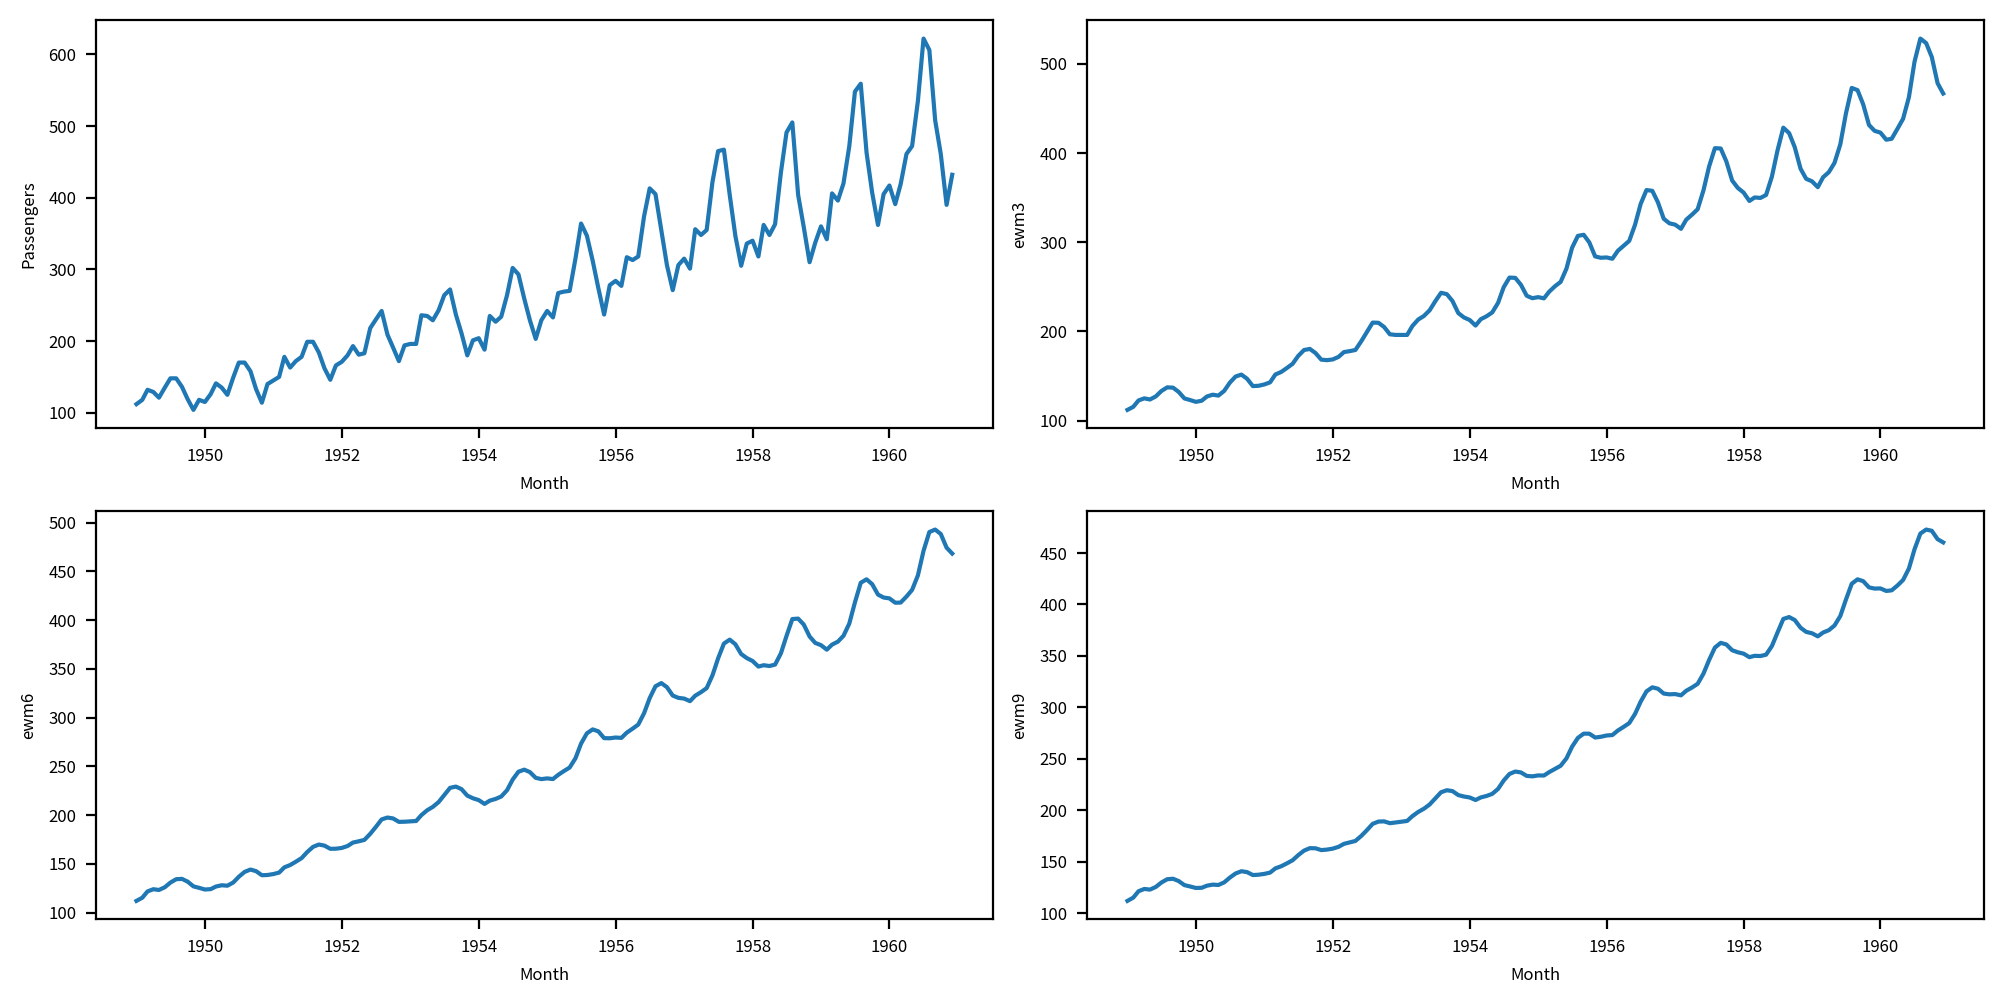

In [62]:
width_px = 2000
height_px = 1000
rows = 2
cols = 2
figsize = (width_px/ my_dpi,height_px/my_dpi)

fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi = my_dpi)

sb.lineplot(df4, x=df4.index, y='Passengers', ax=ax[0][0])
sb.lineplot(df4, x=df4.index, y='ewm3', ax=ax[0][1])
sb.lineplot(df4, x=df4.index, y='ewm6', ax=ax[1][0])
sb.lineplot(df4, x=df4.index, y='ewm9', ax=ax[1][1])

plt.tight_layout()
plt.show()
plt.close()

📝(2)차분 결과에 대한 지수평활법

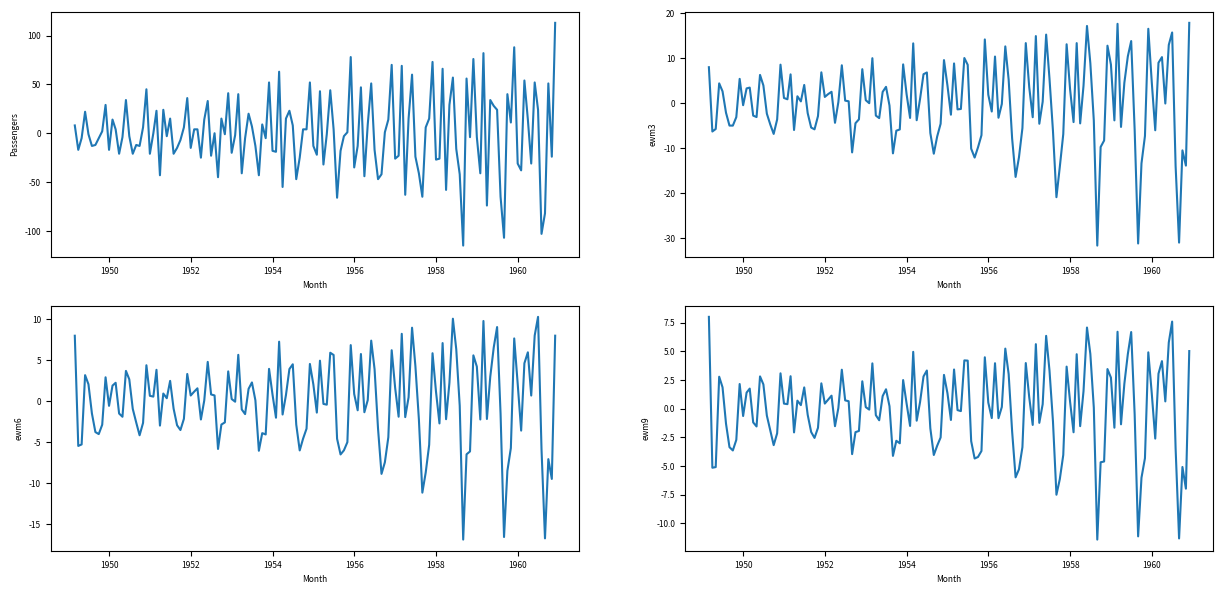

In [65]:
diff_df['ewm3'] = diff_df['Passengers'].ewm(3).mean()
diff_df['ewm6'] = diff_df['Passengers'].ewm(6).mean()
diff_df['ewm9'] = diff_df['Passengers'].ewm(9).mean()

fig, ((ax1,ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(15,7))

sb.lineplot(diff_df, x=diff_df.index, y = 'Passengers', ax=ax1)
sb.lineplot(diff_df, x=diff_df.index, y = 'ewm3', ax=ax2)
sb.lineplot(diff_df, x=diff_df.index, y = 'ewm6', ax=ax3)
sb.lineplot(diff_df, x=diff_df.index, y = 'ewm9', ax=ax4)

plt.show()
plt.close()


평균이동법과 지수평활법은 시각화 결과물을 분석가의 주관대로 해석하는 방법이므로<br>
추론통계보다는 탐색적 데이터 분석 과정에 더 가깝다

#5.분해시계열

📝[1]분해 시계열 생성

In [68]:
# model_name = 'addictive' 가법 모델
model_name = 'multiplicative'

# 분해 시계열 객체 생성
sd = seasonal_decompose(df1['Passengers'], model=model_name)

In [69]:
# trend, seasonal, residual 데이터 프레임으로 변환
sd_df = DataFrame({
    'original':sd.observed,
    'trend':sd.trend,
    'seasonal':sd.seasonal,
    'resid':sd.resid
}, index = origin.index)

# 이걸로는 알 수 없다
sd_df

,original,trend,seasonal,resid
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
139,NaN,NaN,NaN,NaN
140,NaN,NaN,NaN,NaN
141,NaN,NaN,NaN,NaN
142,NaN,NaN,NaN,NaN


📝[2]분해 시계열 시각화

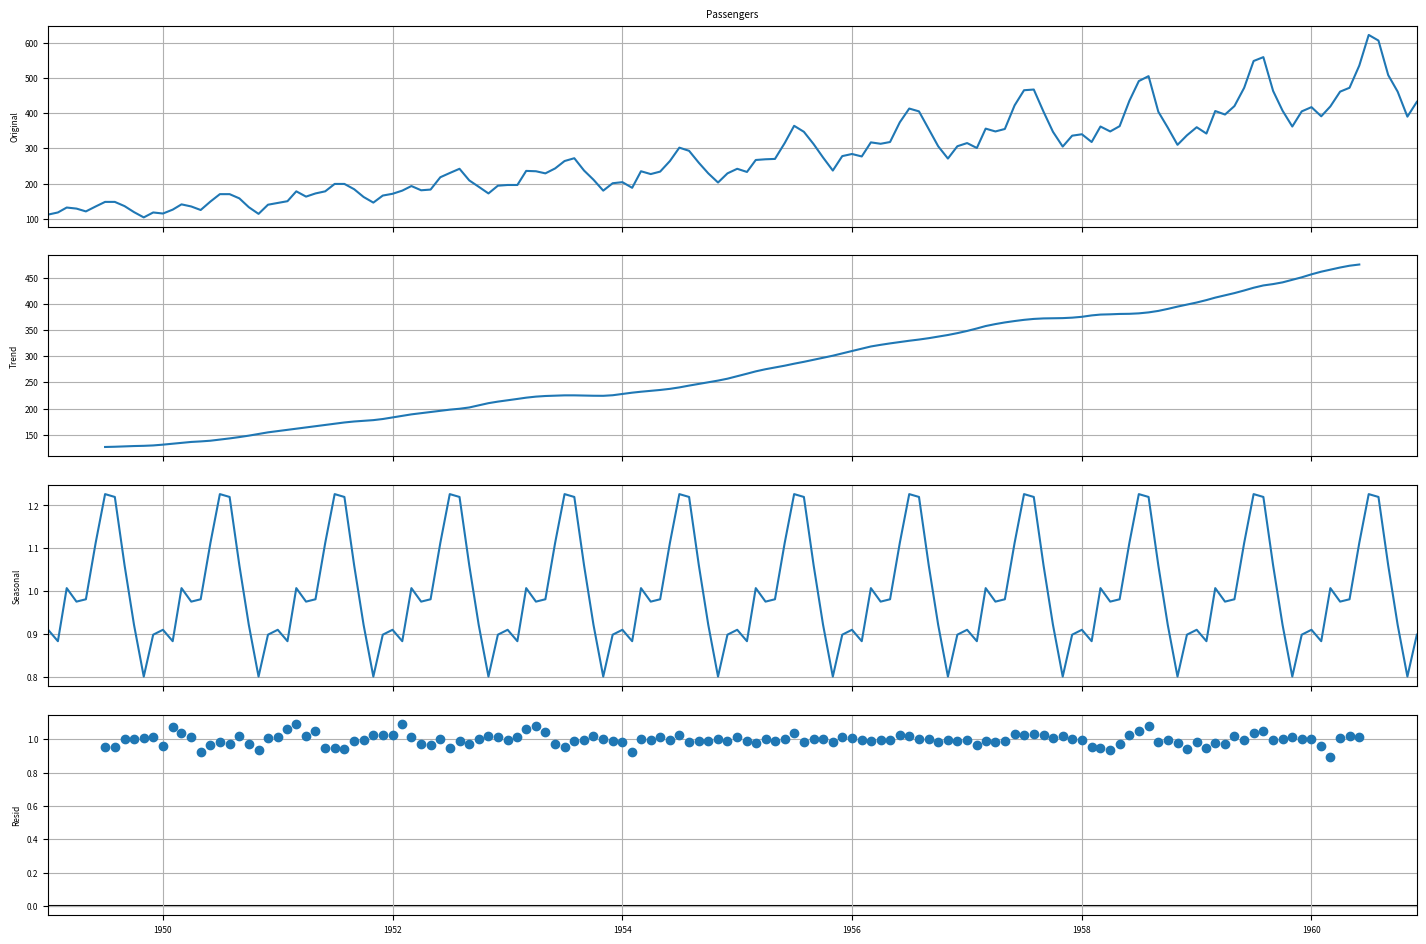

In [71]:
figure = sd.plot()
figure.set_size_inches((15,10))

fig,ax1, ax2, ax3, ax4 = figure.get_children()

ax1.set_ylabel("Original")
ax1.grid(True)
ax2.grid(True)
ax3.grid(True)
ax4.grid(True)

plt.show()
plt.close()